Connected to ni-vedo-env (Python 3.14.0)

 # Notebook 04: pHH3+ mitotic cell density mapping

 **Paper section:** Results — Spatial patterns of mitotic activity are
 preserved across global expansion
 **Paper figures:** Fig. 6

 This script maps the local density of pHH3+ mitotic cells onto the
 basal surface mesh.

 **Method:**
 1. Load pHH3+ spot coordinates (filtered to the tissue wall in `docs/phh3_spots.md`)
 2. Compute a 3D density volume using vedo's kernel density estimation (`density`)
 3. Interpolate the density field onto the basal surface mesh
 4. Smooth the interpolated scalar field on the mesh

 **Output:** `basal-phh3density.npy` — array of shape (N, 4):
 X, Y, Z, density (counts per sphere of radius `density_radius`).

In [1]:
from vedo import settings
settings.default_backend = "vtk"

from spatchcocking import *
import numpy as np
import os
import re

 ## Parameters

In [2]:
# --- Input files ---
mesh_path  = "../data/example/basal.ply"                      # basal surface mesh
spots_path = "../data/example/2025-10-22-12-30-spots.npy"    # pHH3+ spot coordinates

# --- Density estimation ---
density_radius = 100   # sphere radius for kernel density (µm);
                       # should span the full tissue thickness

# --- Output ---
npy_file = "../data/example/basal-phh3density.npy"

 ## Load data

In [3]:
si = Mesh(mesh_path)

spots = np.load(spots_path)
phh3cells = Points(spots, r=4).c("r")

print(f"Loaded {len(spots)} pHH3+ spots")

# Preview: spots overlaid on the basal surface
show(si.alpha(0.5), phh3cells).close()

Loaded 22430 pHH3+ spots


vedo.plotter.runtime.Plotter
n. of objects : 2 (26179 vertices)
bounds        : x=(138, 1.91e+3), y=(645, 3.35e+3), z=(1.35e+3, 4.92e+3)
axes style    : [None]

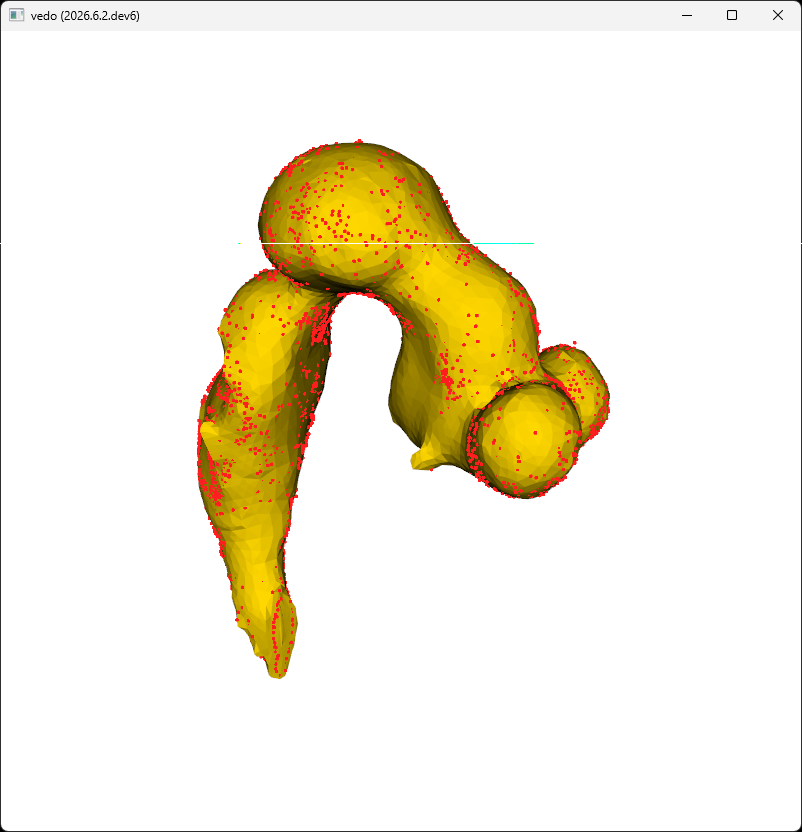

 ## Compute density and map onto mesh

 `points.density(radius)` builds a 3D volumetric density field by counting
 how many spots fall within a sphere of the given radius at each voxel.
 The result is a `Volume` object whose scalar values are counts per sphere.

 We then use `interpolate_data_from` to sample that volume at each vertex
 of the basal mesh, transferring the density field to the surface.

In [ ]:
run_computation = True

if os.path.exists(npy_file):
    answer = input(f"'{npy_file}' already exists. Rerun density analysis? [y/N]: ")
    run_computation = answer.strip().lower() == "y"

if run_computation:
    # Step 1: build volumetric density field from spot point cloud
    vol = phh3cells.density(radius=density_radius)
    vol.cmap("hot").alpha([0.1, 1])
    r = precision(vol.metadata["radius"][0], 2)   # actual radius used (may be auto-adjusted)
    vol.add_scalarbar3d(title=f"Density (counts, r={r} um)", italic=1)
    show(vol, axes=True).close()

    # Step 2: interpolate volume density onto mesh vertices
    # 'ImageScalars' is the default array name vedo assigns after interpolating from a Volume
    si_phh3 = si.clone()
    si_phh3.interpolate_data_from(vol, n=5).cmap("viridis", vmin=0).add_scalarbar()
    show(si_phh3).close()

    # Step 3: smooth the density field on the mesh surface
    si_phh3_smooth = si_phh3.clone()
    si_phh3_smooth.smooth_data(niter=5, relaxation_factor=1).add_scalarbar()
    # show([si_phh3, si_phh3_smooth], N=2).close()

    # Step 4: save
    verts      = si_phh3_smooth.vertices
    phh3density = si_phh3_smooth.pointdata["ImageScalars"]  # density values per vertex
    result     = np.column_stack((verts, phh3density))      # (N, 4): X Y Z density
    np.save(npy_file, result)
    print(f"Saved: {npy_file}  shape={result.shape}")

else:
    # Load from cache and restore to mesh for display
    # cols: X  Y  Z  density
    data = np.load(npy_file)
    si_phh3_smooth = si.clone()
    si_phh3_smooth.pointdata["phh3density"] = data[:, 3]
    si_phh3_smooth.cmap("viridis", "phh3density", vmin=0).add_scalarbar()
    show(si_phh3_smooth).close()
    print(f"Loaded density from {npy_file}")

Saved: ../data/example/basal-phh3density.npy  shape=(3749, 4)


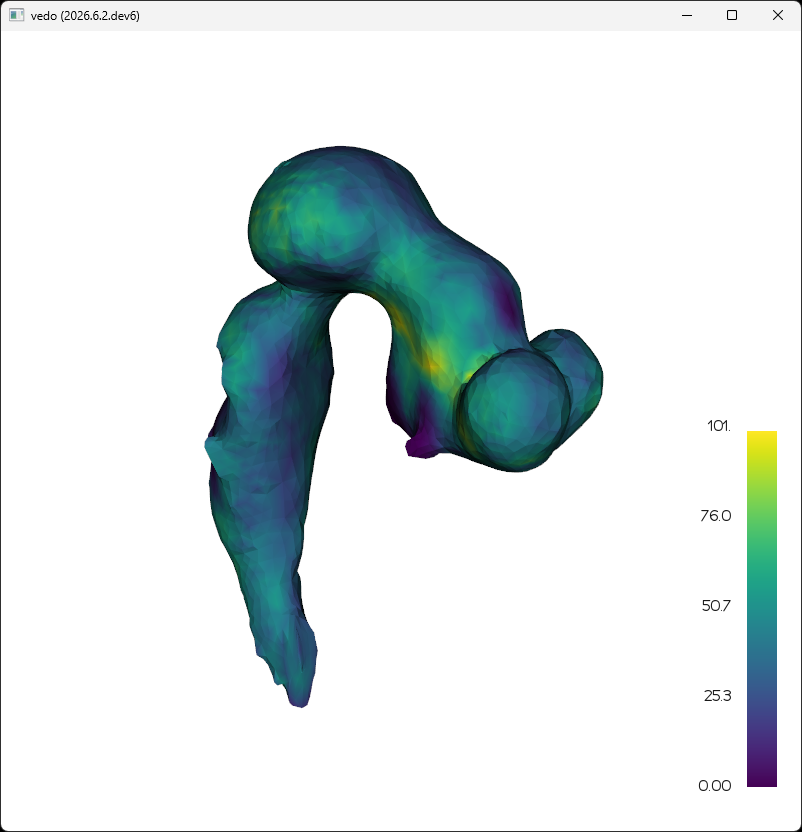